**1. Importing dependencies**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Loaded: {df.shape}')
df.head(3)

Loaded: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


**2. Preprocessing**

In [ ]:
# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Drop customerID
df.drop('customerID', axis=1, inplace=True)

# Binary encode Yes/No columns
binary_cols = ['gender','Partner','Dependents','PhoneService',
               'PaperlessBilling','Churn']
mapping = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
for col in binary_cols:
    df[col] = df[col].map(mapping)

# Multi-value categoricals: one-hot encode
multi_cols = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
              'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
              'Contract','PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print('Shape after encoding:', df.shape)
print('\nFeature list:')
features = [c for c in df.columns if c != 'Churn']
print(features)

Shape after encoding: (7043, 31)

Feature list:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


**3. Train/Test Split & Scaling**

In [ ]:
X = df[features]
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale — critical for Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Train churn rate: {y_train.mean()*100:.1f}%')
print(f'Test  churn rate: {y_test.mean()*100:.1f}%')

Train: (5634, 30) | Test: (1409, 30)
Train churn rate: 26.5%
Test  churn rate: 26.5%


**4. Train Logistic Regression**

In [ ]:
lr_model = LogisticRegression(
    C=1.0,               # Regularisation strength (smaller = more regularised)
    max_iter=1000,
    class_weight='balanced',  # Handles class imbalance (73/26 split)
    solver='lbfgs',
    random_state=42
)
lr_model.fit(X_train_sc, y_train)
print('Model trained!')

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr_model, X_train_sc, y_train, cv=cv, scoring='roc_auc')
print(f'\n5-Fold CV AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')
print(f'Fold scores: {cv_scores.round(4)}')

Model trained!

5-Fold CV AUC: 0.8460 (+/- 0.0125)
Fold scores: [0.8473 0.8255 0.8414 0.8629 0.8531]


**5. Evaluate**

In [ ]:
y_pred  = lr_model.predict(X_test_sc)
y_proba = lr_model.predict_proba(X_test_sc)[:, 1]

print('='*45)
print('     LOGISTIC REGRESSION RESULTS')
print('='*45)
print(classification_report(y_test, y_pred, target_names=['Retained','Churned']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}')

     LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

    Retained       0.90      0.72      0.80      1035
     Churned       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

AUC-ROC: 0.8414


**6. Confusion Matrix & ROC Curve**

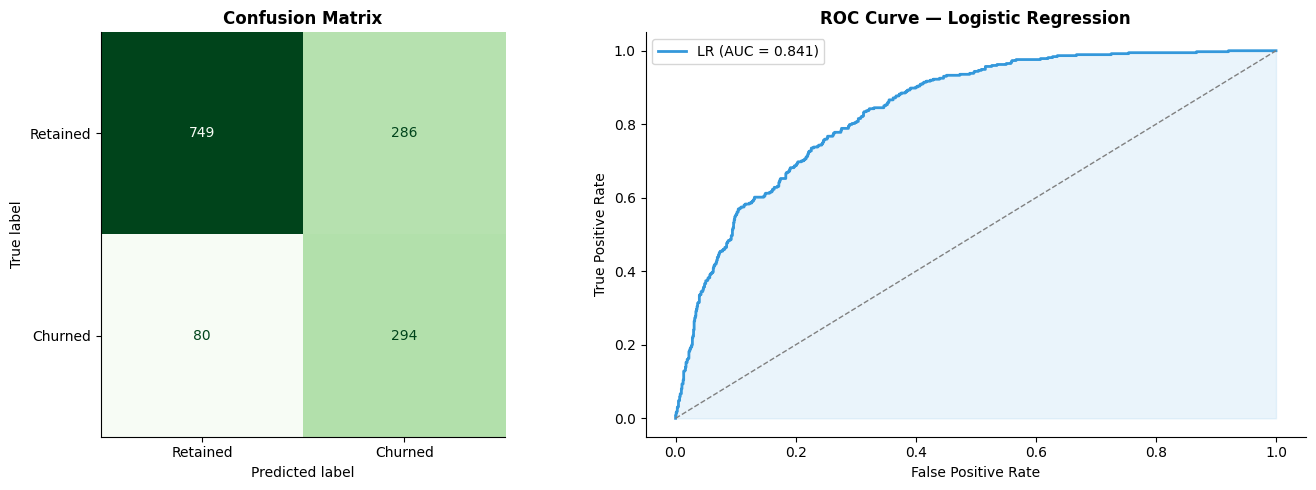

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['Retained','Churned']
).plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#3498db', lw=2, label=f'LR (AUC = {auc:.3f})')
axes[1].plot([0,1],[0,1],'--', color='gray', lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#3498db')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Logistic Regression', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

**7. Feature Coefficients (Interpretability)**

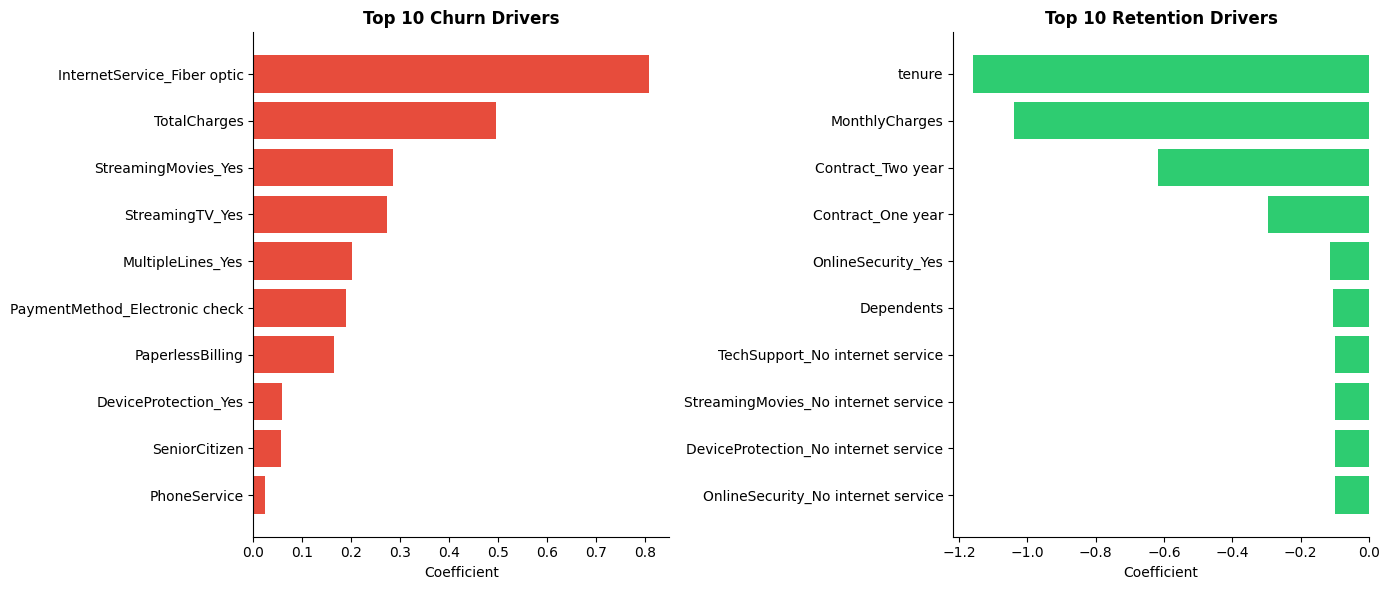


Top 5 churn drivers:
                        feature  coefficient
11  InternetService_Fiber optic     0.808897
8                  TotalCharges     0.494748
24          StreamingMovies_Yes     0.285948
22              StreamingTV_Yes     0.273209
10            MultipleLines_Yes     0.201165

Top 5 retention drivers:
               feature  coefficient
14  OnlineSecurity_Yes    -0.114503
25   Contract_One year    -0.296706
26   Contract_Two year    -0.617746
7       MonthlyCharges    -1.039440
4               tenure    -1.159048


In [ ]:
coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': lr_model.coef_[0]
}).sort_values('coefficient', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 10 churn drivers
top10 = coef_df.head(10)
axes[0].barh(top10['feature'], top10['coefficient'], color='#e74c3c')
axes[0].set_title('Top 10 Churn Drivers', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Coefficient')
axes[0].invert_yaxis()

# Top 10 retention drivers
bot10 = coef_df.tail(10).sort_values('coefficient')
axes[1].barh(bot10['feature'], bot10['coefficient'], color='#2ecc71')
axes[1].set_title('Top 10 Retention Drivers', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Coefficient')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print('\nTop 5 churn drivers:')
print(coef_df[['feature','coefficient']].head())
print('\nTop 5 retention drivers:')
print(coef_df[['feature','coefficient']].tail())

**8. Score All Customers — Churn Probability**

In [ ]:
# Reload original for customerID
df_orig = pd.read_csv('/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv')

all_scaled = scaler.transform(X)   # X is already pre-processed above
df_orig['churn_probability_lr'] = lr_model.predict_proba(all_scaled)[:, 1]
df_orig['risk_segment'] = pd.cut(
    df_orig['churn_probability_lr'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low', 'Medium', 'High']
)

at_risk = df_orig.sort_values('churn_probability_lr', ascending=False)
print('Top 15 at-risk customers:')
print(at_risk[['customerID','tenure','MonthlyCharges','Contract',
               'churn_probability_lr','risk_segment']].head(15).to_string(index=False))

print('\nRisk segment distribution:')
print(df_orig['risk_segment'].value_counts())

# Save predictions
at_risk[['customerID','churn_probability_lr','risk_segment']].to_csv(
    'lr_churn_predictions.csv', index=False)
print('\nSaved: lr_churn_predictions.csv')

Top 15 at-risk customers:
customerID  tenure  MonthlyCharges       Contract  churn_probability_lr risk_segment
9497-QCMMS       1           93.55 Month-to-month              0.939697         High
9300-AGZNL       1           94.00 Month-to-month              0.938817         High
4424-TKOPW       2           93.85 Month-to-month              0.937675         High
5178-LMXOP       1           95.10 Month-to-month              0.937634         High
2720-WGKHP       2           94.00 Month-to-month              0.937180         High
5567-WSELE       3           94.60 Month-to-month              0.935431         High
7024-OHCCK       2           93.85 Month-to-month              0.935429         High
5150-ITWWB       3           94.85 Month-to-month              0.934597         High
1374-DMZUI       4           94.30 Month-to-month              0.932037         High
7216-EWTRS       1          100.80 Month-to-month              0.931205         High
8098-LLAZX       4           95.45 Mont